In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

In [12]:
image_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(root='malimg_dataset/train', transform=image_transforms)
val_dataset = datasets.ImageFolder(root='malimg_dataset/val', transform=image_transforms)
test_dataset = datasets.ImageFolder(root='malimg_dataset/test', transform=image_transforms)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

print("Dataset loaded successfully.")
print(f"Total training images: {len(train_dataset)}")
print(f"Total validation images: {len(val_dataset)}")
print(f"Total test images: {len(test_dataset)}")

Dataset loaded successfully.
Total training images: 7459
Total validation images: 923
Total test images: 957


Batch shape: torch.Size([16, 1, 224, 224])


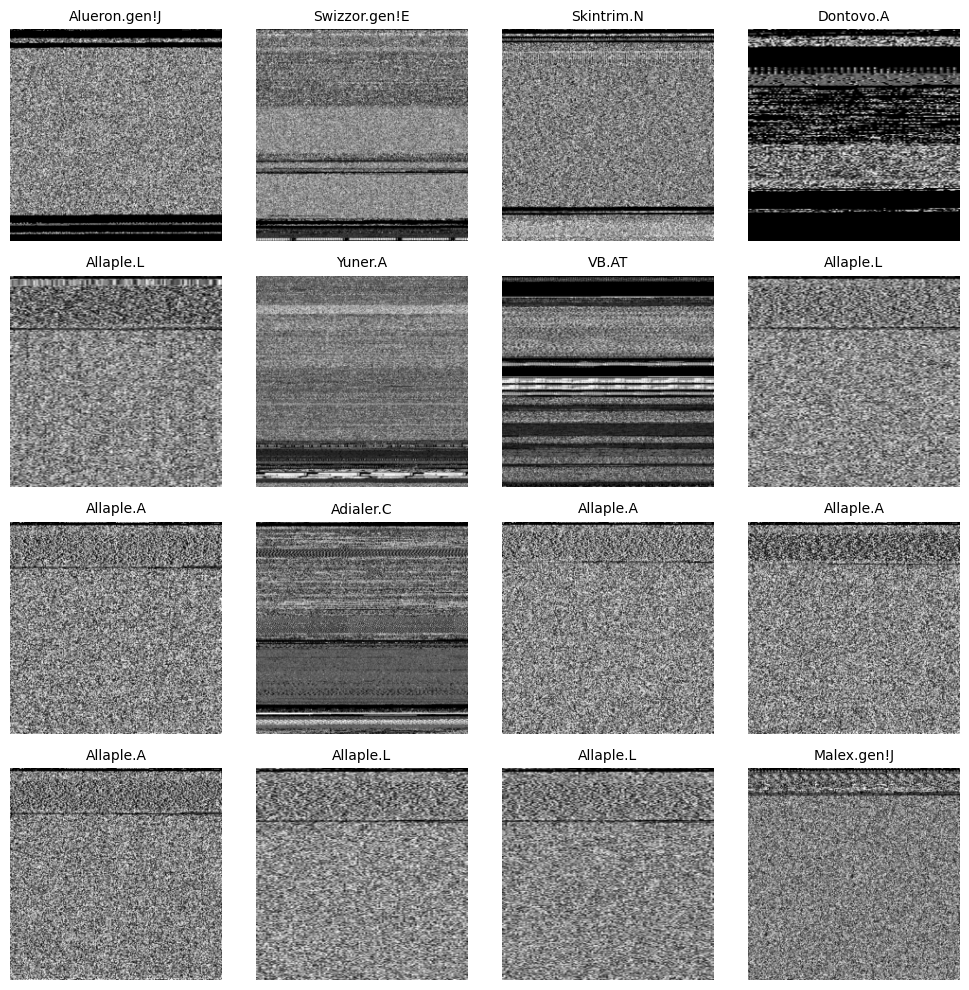

In [3]:
data_iterator = iter(train_loader)
images, labels = next(data_iterator)

print("Batch shape:", images.shape)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()

    label_idx = labels[i].item()
    family_name = train_dataset.classes[label_idx]
    
    ax.imshow(img, cmap='gray')
    ax.set_title(family_name, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [5]:
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet_model.conv1 = nn.Conv2d(
    in_channels=1, 
    out_channels=64, 
    kernel_size=7, 
    stride=2, 
    padding=3, 
    bias=False
)

num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, 25)

# Verify the modifications
print("Modified Input Layer:", resnet_model.conv1)
print("Modified Output Layer:", resnet_model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/lakshya/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:17<00:00, 2.68MB/s]


Modified Input Layer: Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Modified Output Layer: Linear(in_features=512, out_features=25, bias=True)


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

resnet_model = resnet_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.parameters(), lr=0.001)

num_epochs = 5

print("Beginning Training Loop...")

for epoch in range(num_epochs):
    # TRAINING PHASE
    resnet_model.train()  
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = resnet_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = (correct_predictions / total_samples) * 100
    
    
    # VALIDATION PHASE
    resnet_model.eval()  # Switch model to evaluation mode
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    # Disable gradient calculation
    with torch.no_grad():
        for val_images, val_labels in val_loader:
            val_images = val_images.to(device)
            val_labels = val_labels.to(device)
            
            # Forward pass only
            val_outputs = resnet_model(val_images)
            v_loss = criterion(val_outputs, val_labels)
            
            val_loss += v_loss.item()
            _, val_predicted = torch.max(val_outputs.data, 1)
            val_total += val_labels.size(0)
            val_correct += (val_predicted == val_labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = (val_correct / val_total) * 100
    
    # Print the combined statistics for the epoch
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train      -> Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")
    print(f"  Validation -> Loss: {epoch_val_loss:.4f} | Accuracy: {epoch_val_acc:.2f}%\n")

print("Training Complete.")

Training on device: cuda
Beginning Training Loop...
Epoch [1/5]
  Train -> Loss: 0.1270 | Accuracy: 96.45%
  Validation -> Loss: 0.0954 | Accuracy: 97.07%

Epoch [2/5]
  Train -> Loss: 0.0774 | Accuracy: 97.52%
  Validation -> Loss: 0.0721 | Accuracy: 97.94%

Epoch [3/5]
  Train -> Loss: 0.0692 | Accuracy: 97.90%
  Validation -> Loss: 0.0653 | Accuracy: 98.05%

Epoch [4/5]
  Train -> Loss: 0.0786 | Accuracy: 97.57%
  Validation -> Loss: 0.1265 | Accuracy: 96.32%

Epoch [5/5]
  Train -> Loss: 0.0590 | Accuracy: 98.15%
  Validation -> Loss: 0.0615 | Accuracy: 97.94%

Training Complete.


In [13]:
# Save model
torch.save(resnet_model.state_dict(), 'bytesight_resnet_prototype.pth')

In [14]:
resnet_model.eval()
test_correct = 0
test_total = 0

print("Running Final Test Set Evaluation...")

with torch.no_grad():
    for test_images, test_labels in test_loader:

        test_images = test_images.to(device)
        test_labels = test_labels.to(device)
        
        test_outputs = resnet_model(test_images)
        
        _, test_predicted = torch.max(test_outputs.data, 1)
        test_total += test_labels.size(0)
        test_correct += (test_predicted == test_labels).sum().item()

final_accuracy = (test_correct / test_total) * 100
print(f"Final Test Accuracy: {final_accuracy:.2f}%")

Running Final Test Set Evaluation...
Final Test Accuracy: 98.01%


Gathering test set predictions...


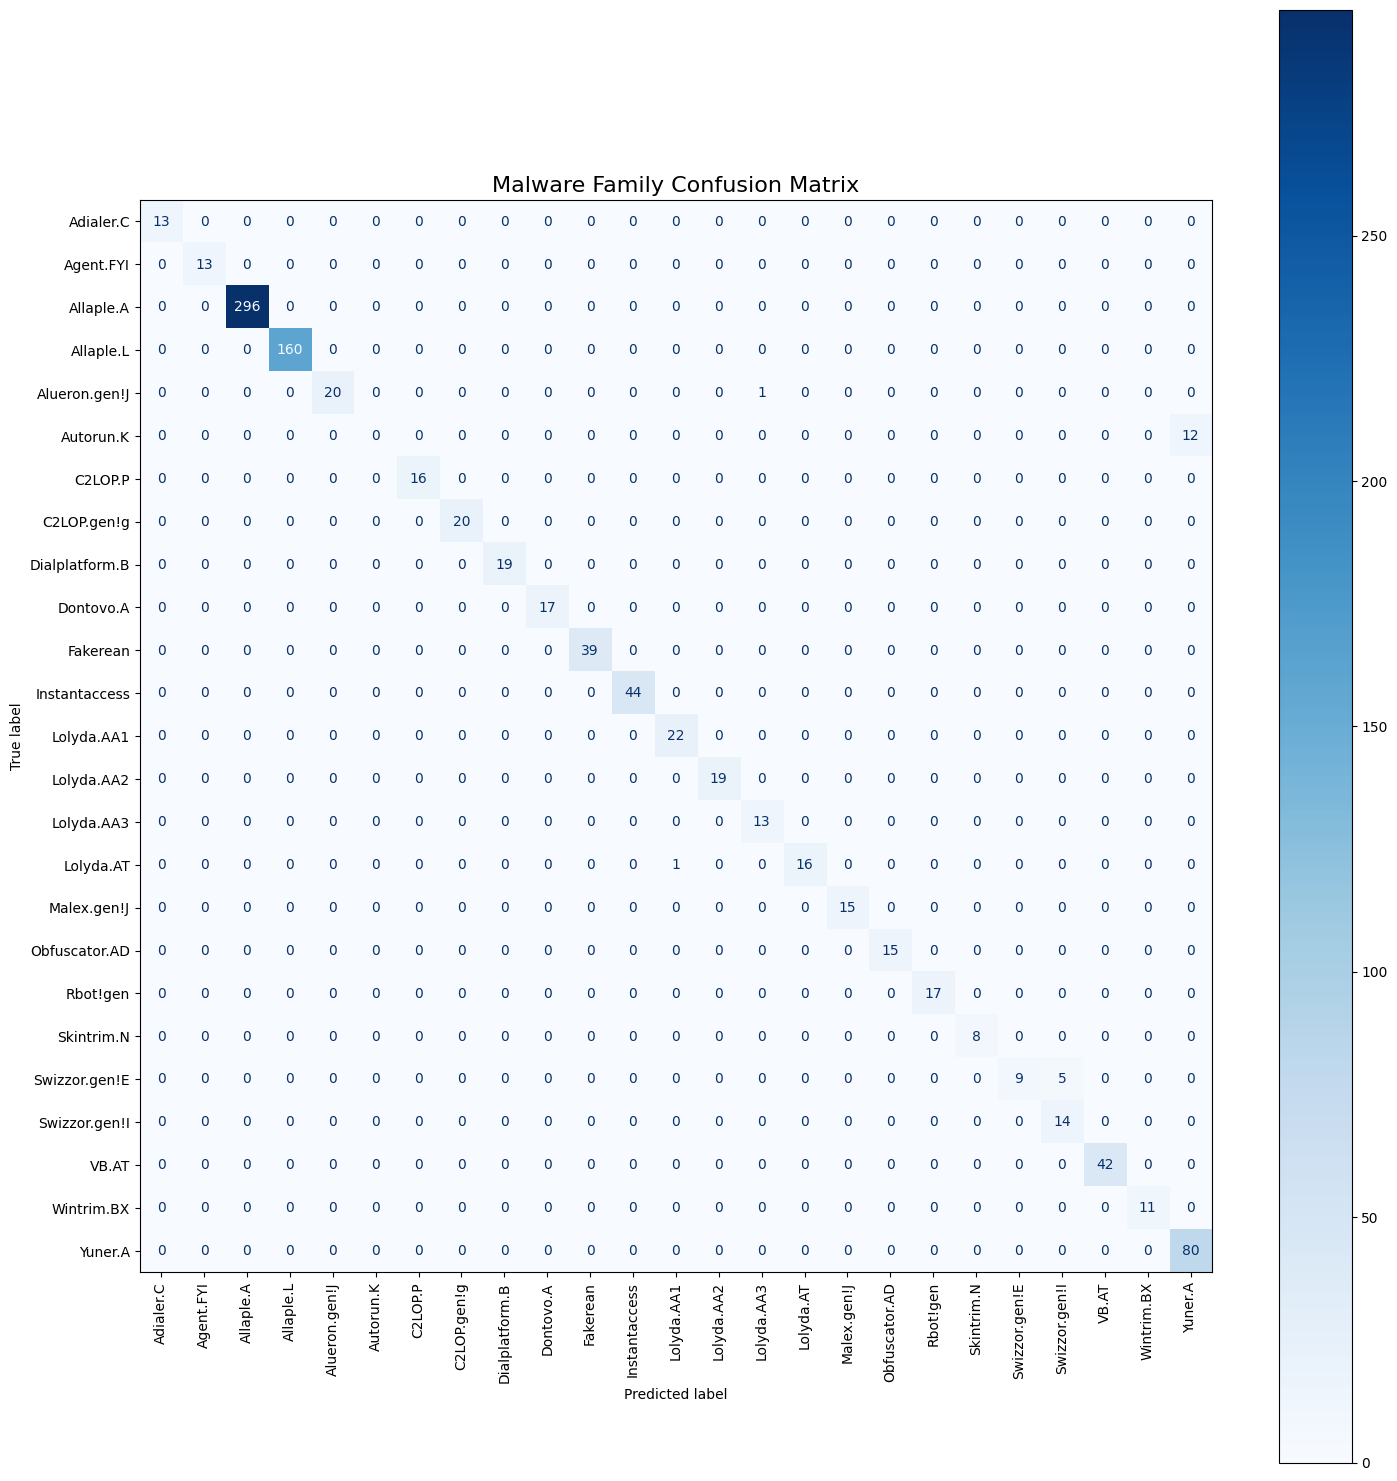

In [16]:
all_predictions = []
all_true_labels = []

resnet_model.eval()

print("Gathering test set predictions...")

with torch.no_grad():
    for test_images, test_labels in test_loader:
        test_images = test_images.to(device)
        
        # Get network predictions
        outputs = resnet_model(test_images)
        _, predicted = torch.max(outputs, 1)
        
        # Move the data from the GPU back to the CPU, then convert to standard NumPy arrays
        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(test_labels.numpy())


cm = confusion_matrix(all_true_labels, all_predictions)

fig, ax = plt.subplots(figsize=(15, 15))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)

# Render the plot using a blue color map
# Rotating the x-ticks vertically prevents the 25 names from overlapping
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')

plt.title("Malware Family Confusion Matrix", fontsize=16)
plt.tight_layout()
plt.show()